In [1]:
import pandas as pd

In [3]:
drug_df = pd.read_csv('data/drug.csv').sample(frac = 1).reset_index(drop = True)
drug_df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,47,M,LOW,HIGH,10.114,drugC
1,58,F,HIGH,NORMAL,14.239,drugB
2,64,F,LOW,NORMAL,25.741,DrugY
3,59,M,HIGH,HIGH,13.935,drugB
4,39,M,LOW,NORMAL,13.938,drugX


In [4]:
from sklearn.model_selection import train_test_split
X = drug_df.drop('Drug', axis = 1)
y = drug_df['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 125)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [7]:
cat_cols = ['Sex', 'BP', 'Cholesterol']
num_cols = ['Age', 'Na_to_K']

transform = ColumnTransformer(transformers = [
    ('encoder', OneHotEncoder(), cat_cols),
    ('num_imputer', SimpleImputer(strategy = 'mean'), num_cols),
    ('num_scaler', StandardScaler(), num_cols)
])

pipe = Pipeline(
    steps = [
        ('preprocessing', transform),
        ('model', RandomForestClassifier(random_state = 125))
    ]
)

In [8]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...), ('num_imputer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
from sklearn.metrics import accuracy_score, f1_score

predictions = pipe.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average = 'macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 1.0000
F1 Score: 1.0000


In [11]:
with open('results/metrics.txt', 'w') as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"F1 Score: {f1:.4f}\n")

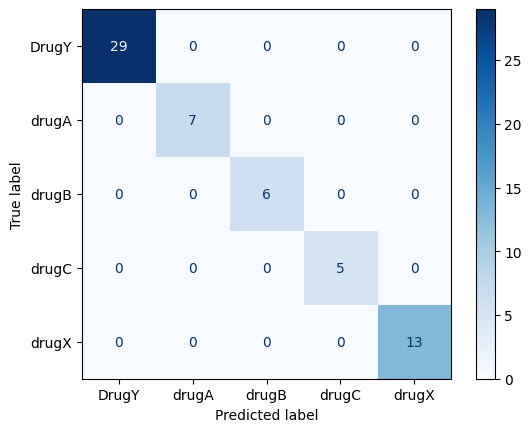

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = pipe.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.savefig('results/confusion_matrix.png', dpi=120, bbox_inches='tight')

In [15]:
import skops.io as sio
sio.dump(pipe, 'model/drug_pipeline.skops')

In [ ]:
from skops.io import get_untrusted_types

trusted_types = get_untrusted_types("model/drug_pipeline.skops")
print(trusted_types)  # review before trusting

loaded_pipe = sio.load("model/drug_pipeline.skops", trusted=trusted_types)

TypeError: trusted must be a list of strings. Before version 0.10 trusted could be a boolean, but this is no longer supported, due to a reported CVE-2024-37065. You can pass the output of `get_untrusted_types` as trusted to load the data. Be sure to review the output of the function before passing it as trusted.